In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle
from matplotlib.colors import LogNorm  # Import LogNorm for logarithmic color scale

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

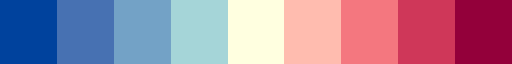

In [3]:
my_cmap

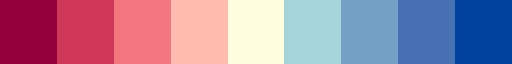

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [6]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm


def metric_VectorDecomposition_onlyPositive(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    
    x1=(e12[0])*(e12[0]>0)
    x2=(e12[1])*(e12[1]>0)
    x3=np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))
    convert=np.sqrt((1-x3**2)/(x1**2+x2**2))
    
    return convert*x1, convert*x2, x3

def calculate_assymetricity(u,v,k):
    x=np.sqrt(np.array(u)**2+np.array(v)**2)
    y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)  
    return x,y

def characterize_case(x,y):
    if (x**2>0.5)*(y>0.5):
        return 0
    if (x**2>0.5)*(y<0.5):
        return 1
    if (x**2<0.5):
        return 2

########################################################
########################################################
# Fig 3-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [7]:
def pHcriteria(pH_list,return_type="Num"):
    pH_list=np.array(pH_list)
    O=1*(pH_list>6)+1*(pH_list>8)
    if return_type=="Num":
        return O
    if return_type=="Word":
        word_list=['acidic','neutral','alkalic']
        return [word_list[x] for x in O]
    if return_type=="Color":
        word_list=['r','g','b']
        return [word_list[x] for x in O]

def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={Sub_IDX : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[SampleIDX].update({SampleIDX:0.5})
    
    return matrix   

def EstimateErrorLassoRegression2(matrix, order, alpha, beta, preprocess='Normalize', verbose=False):
    train_mse_list=[]
    test_mse_list=[]
    IDX_list1=[]
    IDX_list2=[]
    x=[]
    y=[]
    for i,C_1 in enumerate(matrix):
        for j,C_2 in enumerate(matrix[C_1]):
            IDX_list1.append(C_1)
            IDX_list2.append(C_2)
            y.append(matrix[C_1][C_2])
    y=np.array(y)
    x=np.array(getAbundance_fromList(Processed_sequences_synthetic,IDX_list1))-np.array(getAbundance_fromList(Processed_sequences_synthetic,IDX_list2))

    if preprocess=='Basic':
        y_tofit=y.copy()
    elif preprocess=='Normalize':
        y_tofit=(y.copy()-0.5)*2
    elif preprocess=='Tan':
        y_tofit=np.tan((y.copy()-0.5)*np.pi/2)
    
    fig=plt.figure(figsize=(70*mm,60*mm))
    
    for i, (IDX1, IDX2) in enumerate(zip(IDX_list1, IDX_list2)):
        if IDX1==IDX2:
            continue
        community_IDX1=np.unique(getCommunities(Communities_data,[IDX1])['CommunityIDX'])[0]
        community_IDX2=np.unique(getCommunities(Communities_data,[IDX2])['CommunityIDX'])[0]
        print(community_IDX1,community_IDX2)
        
        #ToTestIndex=(getCommunities(Communities_data,IDX_list1)['CommunityIDX']==community_IDX1) & (getCommunities(Communities_data,IDX_list2)['CommunityIDX']==community_IDX2)
        print(np.where(getCommunities(Communities_data,IDX_list1)['CommunityIDX']==community_IDX1))
        print(np.where(getCommunities(Communities_data,IDX_list2)['CommunityIDX']==community_IDX2))


        '''
        train_idx_list=np.where(~ToTestIndex)[0]
        test_idx_list=np.where(ToTestIndex)[0]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)

        # Predict the target values for the test set
        y_pred_train = model.predict(X_train_poly)
        y_pred_test = model.predict(X_test_poly)

        # Evaluate the model
        train_mse = np.mean((y_train-y_pred_train)**2)
        test_mse = np.mean((y_test-y_pred_test)**2)
        ref_mse= np.var(y_tofit)
        if verbose:
            print(f'Mean Train Squared Error: {train_mse}')
            print(f'Mean Test Squared Error: {test_mse, y_test, y_pred_test}')
        plt.scatter(y_test,y_pred_test)
        train_mse_list.append(train_mse/ref_mse)
        test_mse_list.append(test_mse/ref_mse)
    
    range_min=min(plt.xlim()[0],plt.ylim()[0])
    range_max=max(plt.xlim()[1],plt.ylim()[1])
    plt.plot([range_min, range_max],  [range_min,range_max], color='r')
    print([range_min, range_max],  [range_min,range_max])
    plt.text(range_max, range_max, f'Error={mean(test_mse_list)}',color='r', fontsize=6)
    if True:
        getCommunities(Communities_data,Community_PermutateList("F", com_type, medium, "S", species_num, rep))
        train_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX'])[0]
        test_idx_list=[]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        #X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)
        '''
        
    return communityIDX_list, train_mse_list, test_mse_list ,model, polynomial_features
    

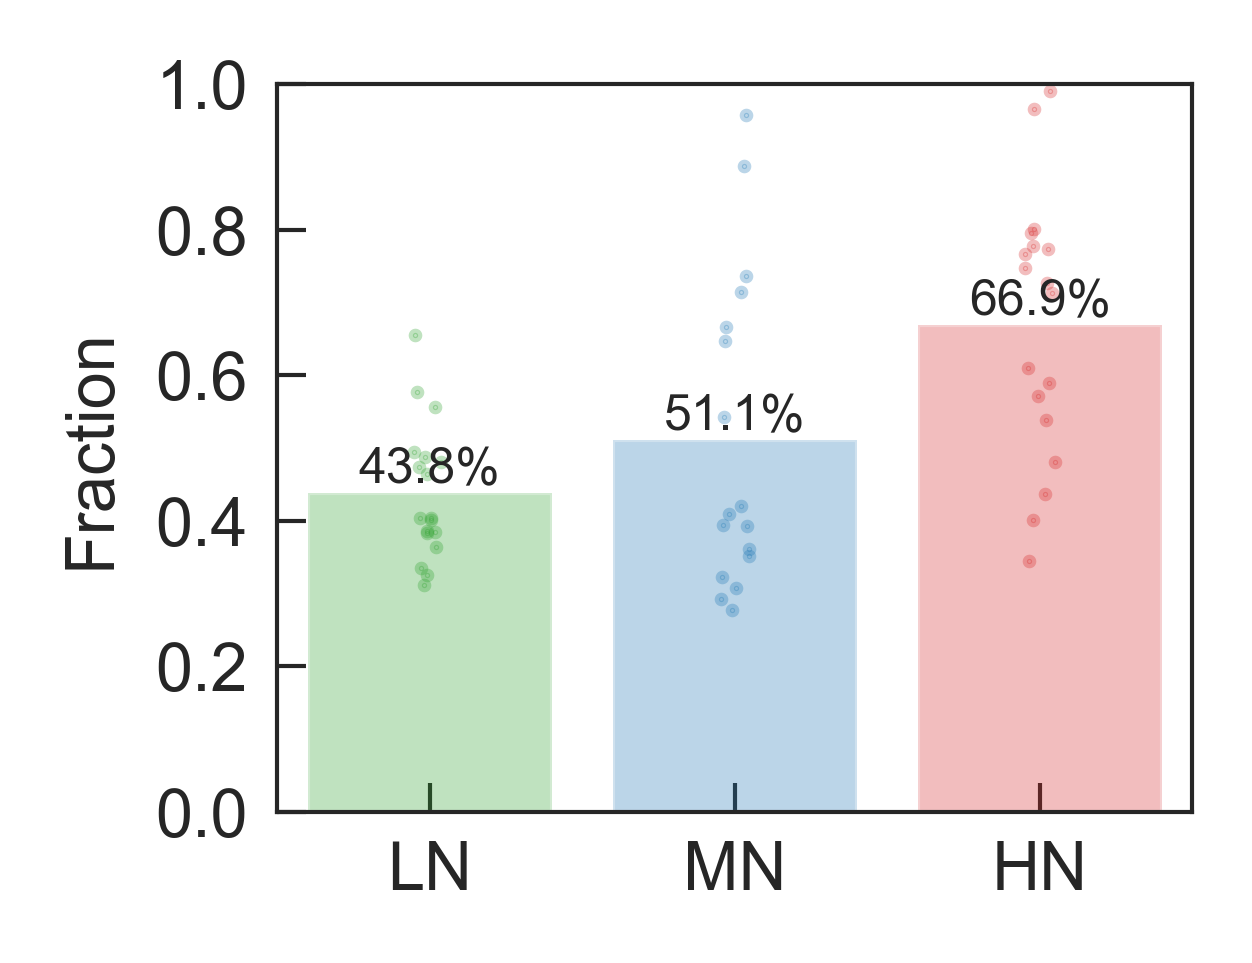

In [9]:
colors=["grey", my_cmap(0), "blue"]
colors_points=([sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]])

data={}

for c_i, medium in enumerate(['L', 'M', 'H']):   
    IDX_list=np.sort(Community_PermutateList("F", "S", medium, "S", 12, -1))
    IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    df=Processed_sequences_synthetic.iloc[IDX_list_]
    index=np.argmax(np.array(df.values[:,1:]),1)+1
    val = [df.values[i,index[i]] for i in range(len(df))]
    data[c_i]=val
    

fig=plt.figure(figsize=(50*mm,40*mm))

x=[0,1,2]
y=np.nan_to_num([np.mean(data[i]) for i in data.keys()])
yerr=np.nan_to_num([np.std(data[i])/np.sqrt(len(data[i])) for i in data.keys()])

for i in range(3):
    if len(data[i])==0:
        continue
    random_component=(0.1*(np.random.rand(len(data[i]))-0.5))
    plt.scatter([x[i]]*len(data[i])+random_component, data[i], s=0.4, color= colors_points[i], alpha=0.3)

bars = plt.bar(x, y, color=colors_points, alpha=0.3, linewidth=0.5)

# Add text labels to the bars
for bar, value in zip(bars, y):
    plt.text(bar.get_x() + bar.get_width() / 2, value, str(round(value*100, 1))+'%', ha='center', fontsize=6, va='bottom')

    
plt.xticks([])

# Add custom x tick labels
custom_x_ticks = [0, 1, 2]
custom_x_labels = ['LN', 'MN', 'HN']

plt.xticks(custom_x_ticks, custom_x_labels)

plt.xlim(-0.5, 2.5)
plt.ylim(0, 1)
plt.ylabel('Fraction')
#plt.title('Case1')

# Display the plot
plt.savefig('Figure/Fig_Abundant.svg', bbox_inches='tight')


In [10]:
Pairwise_Count_data_path="../../Postprocessed/PairwiseColonyCountings_processed_230915.xlsx"

def getPairwiseCountData():
    Mono_Count_data={}
    Pairwise_Count_data={}
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=0)
    Data=np.transpose(np.array(Data.values[:,1:]))
    Mono_Count_data["LN"]=Data
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=1)
    Data=np.transpose(np.array(Data.values[:,1:]))
    Mono_Count_data["MN"]=Data
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=2)
    Data=np.transpose(np.array(Data.values[:,1:]))
    Mono_Count_data["HN"]=Data
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=3)
    Data=np.array(Data.values[:,1:])
    Data_1=Data #This is the species for the first index
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=4)
    Data=np.array(Data.values[:,1:])
    Data_2=Data #This is the species for the second index
    Data=np.stack([Data_1,Data_2])
    Pairwise_Count_data["LN"]=Data

    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=5)
    Data=np.array(Data.values[:,1:])
    Data_1=Data #This is the species for the first index
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=6)
    Data=np.array(Data.values[:,1:])
    Data_2=Data #This is the species for the second index
    Data=np.stack([Data_1,Data_2])
    Pairwise_Count_data["MN"]=Data

    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=7)
    Data=np.array(Data.values[:,1:])
    Data_1=Data #This is the species for the first index
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=8)
    Data=np.array(Data.values[:,1:])
    Data_2=Data #This is the species for the second index
    Data=np.stack([Data_1,Data_2])
    Pairwise_Count_data["HN"]=Data
    return Mono_Count_data, Pairwise_Count_data

def getProcessedPairwiseCountData(Mono_Count_data, Pairwise_Count_data, medium_type):
    data_m=np.mean(Mono_Count_data[medium_type],1)
    data_p_1=Pairwise_Count_data[medium_type][0,:]
    data_p_2=Pairwise_Count_data[medium_type][1,:]
    data_flag=np.array([[None] * 12]*12)
    data_p_1_converted=np.array([[None] * 12]*12)
    data_p_2_converted=np.array([[None] * 12]*12)
    data_p_ratio=np.array([[None] * 12]*12)

    count=0
    for i in range(12):
        for j in range(12):
            if np.isnan(data_p_1[i,j]):
                data_flag[i,j]='case0' # No data
            else:
                if data_p_1[i,j]==1 and data_p_2[i,j]==0 :
                    #print(i,j,'case1') # species i dominates
                    data_flag[i,j]='case1'
                    data_p_1_converted[i,j]=1
                    data_p_2_converted[i,j]=0
                    data_p_ratio[i,j]=1

                elif data_p_1[i,j]==0 and data_p_2[i,j]==1 :
                    #print(i,j,'case2') # species j dominates
                    data_flag[i,j]='case2'
                    data_p_1_converted[i,j]=0
                    data_p_2_converted[i,j]=1
                    data_p_ratio[i,j]=0

                else:
                    #print(i,j,'case3') # species i, j coexists
                    data_flag[i,j]='case3'
                    data_p_1_converted[i,j]=data_p_1[i,j]/data_m[i]
                    data_p_2_converted[i,j]=data_p_2[i,j]/data_m[j]
                    data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])
    return data_p_1,data_p_2,data_flag,data_p_ratio



Mono_Count_data,Pairwise_Count_data=getPairwiseCountData()
data_p_1,data_p_2,data_flag,data_p_ratio=getProcessedPairwiseCountData(Mono_Count_data, Pairwise_Count_data, 'MN')

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_31169/2755529294.py:77: RuntimeWarning: invalid value encountered in scalar divide
  data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_31169/2755529294.py:77: RuntimeWarning: invalid value encountered in scalar divide
  data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])


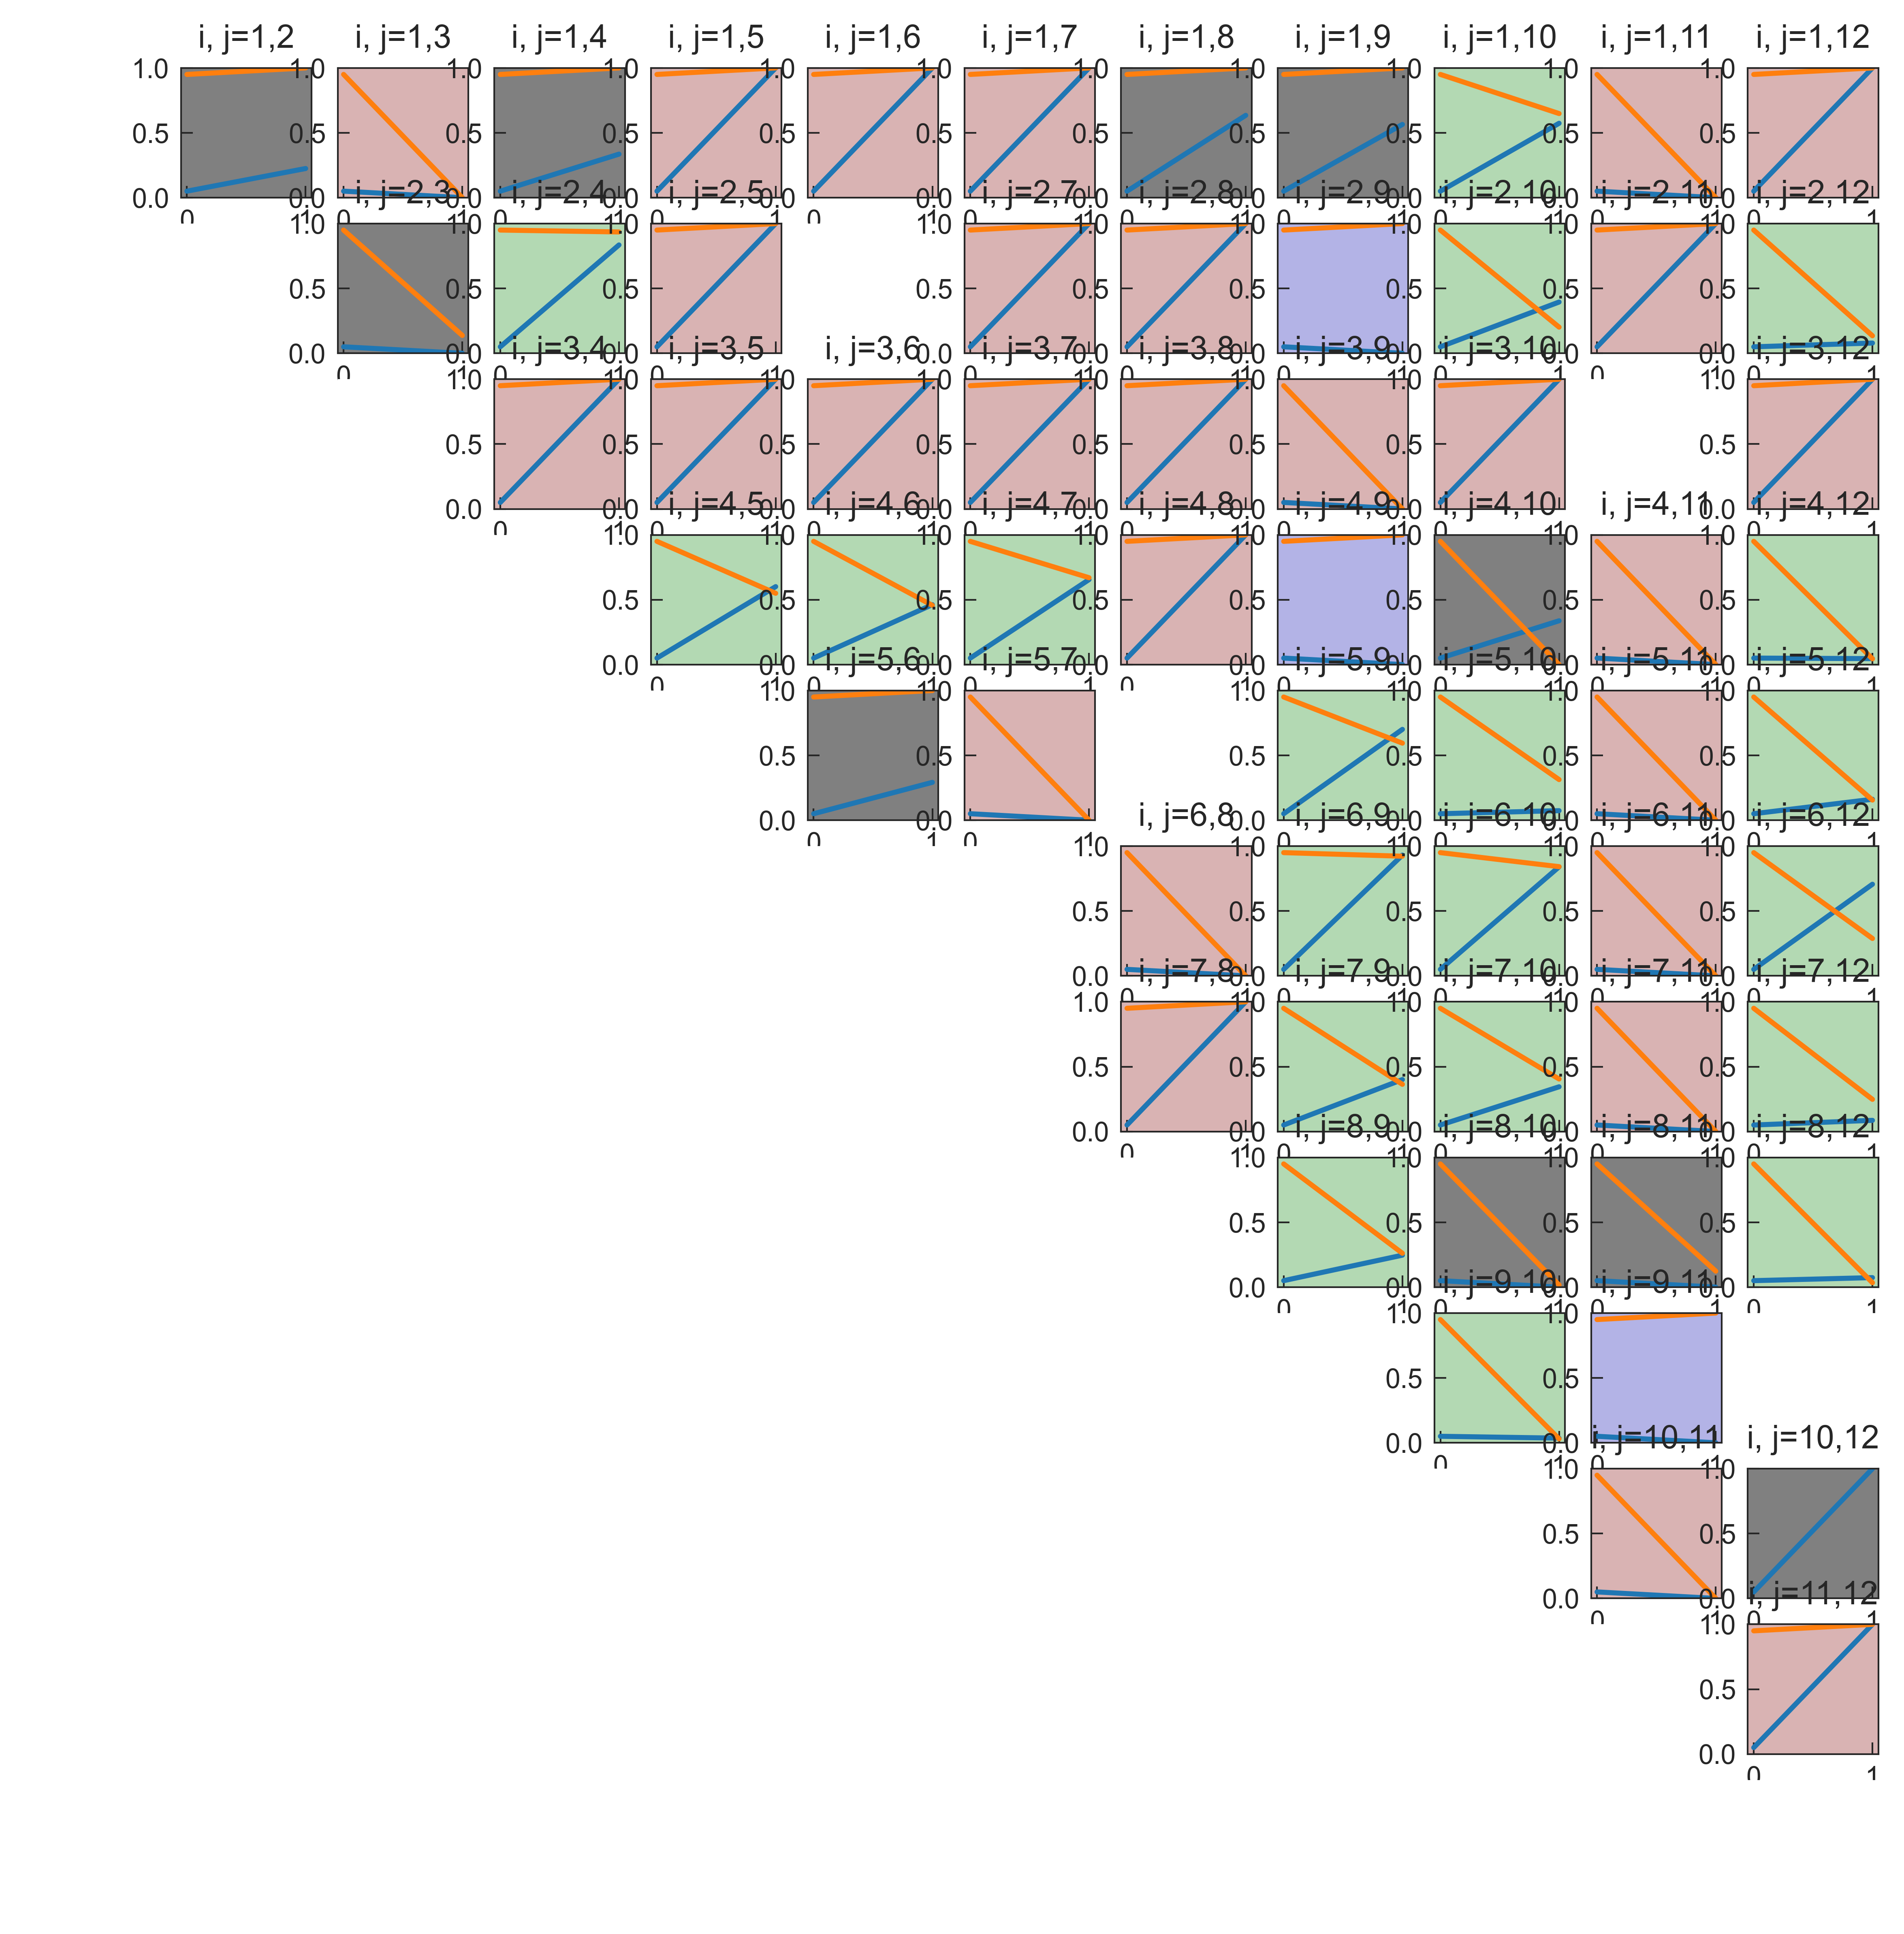

In [11]:
data_p_1,data_p_2,data_flag,data_p_ratio=getProcessedPairwiseCountData(Mono_Count_data, Pairwise_Count_data, 'MN')

def drawPairwiseChange(i, j, x):
    # This is just a sample function. Replace this with your function.
    return np.sin(i*x) + np.cos(j*x)

def InterpretPairwiseResult(y1,y2):
    if y1==1 and y2==1:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==0:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==1:
        return 'B',(0.7, 0.7, 0.9) #B : Bistability
    elif y1>0 and y1<1 and y2>0 and y2<1:
        return 'C',(0.7, 0.85, 0.7) #C : Coexistence
    else:
        return 'U',(0.5, 0.5, 0.5) #U : Unclassified

N=12
fig, axs = plt.subplots(N, N, figsize=(250*mm,250*mm))

case_list=[];
for i in range(12):
    for j in range(12):
        if j<=i:
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        elif data_flag[i,j]=='case0':
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        else:    
            x1=[0,1]
            y1=[0.05,data_p_ratio[i,j]]
            axs[i, j].plot(x1, y1)
            x2=[0,1]
            y2=[0.95,1-data_p_ratio[j,i]]
            axs[i, j].plot(x2, y2)
            
            axs[i, j].set_ylim(0,1)
            
            case,shade = InterpretPairwiseResult(y1[1],y2[1])
            case_list.append(case)
            axs[i, j].set_facecolor(shade)
            #axs[i, j].patch.set_alpha(0.5)
            
            axs[i, j].set_title(f'i, j={i+1},{j+1}')
        # Other subplot-specific formatting goes here

Aligned points: 48 / 98 = 0.490
6 104
Aligned points: 46 / 76 = 0.605
18 94
Aligned points: 80 / 104 = 0.769
0 104


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_31169/2755529294.py:77: RuntimeWarning: invalid value encountered in scalar divide
  data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])


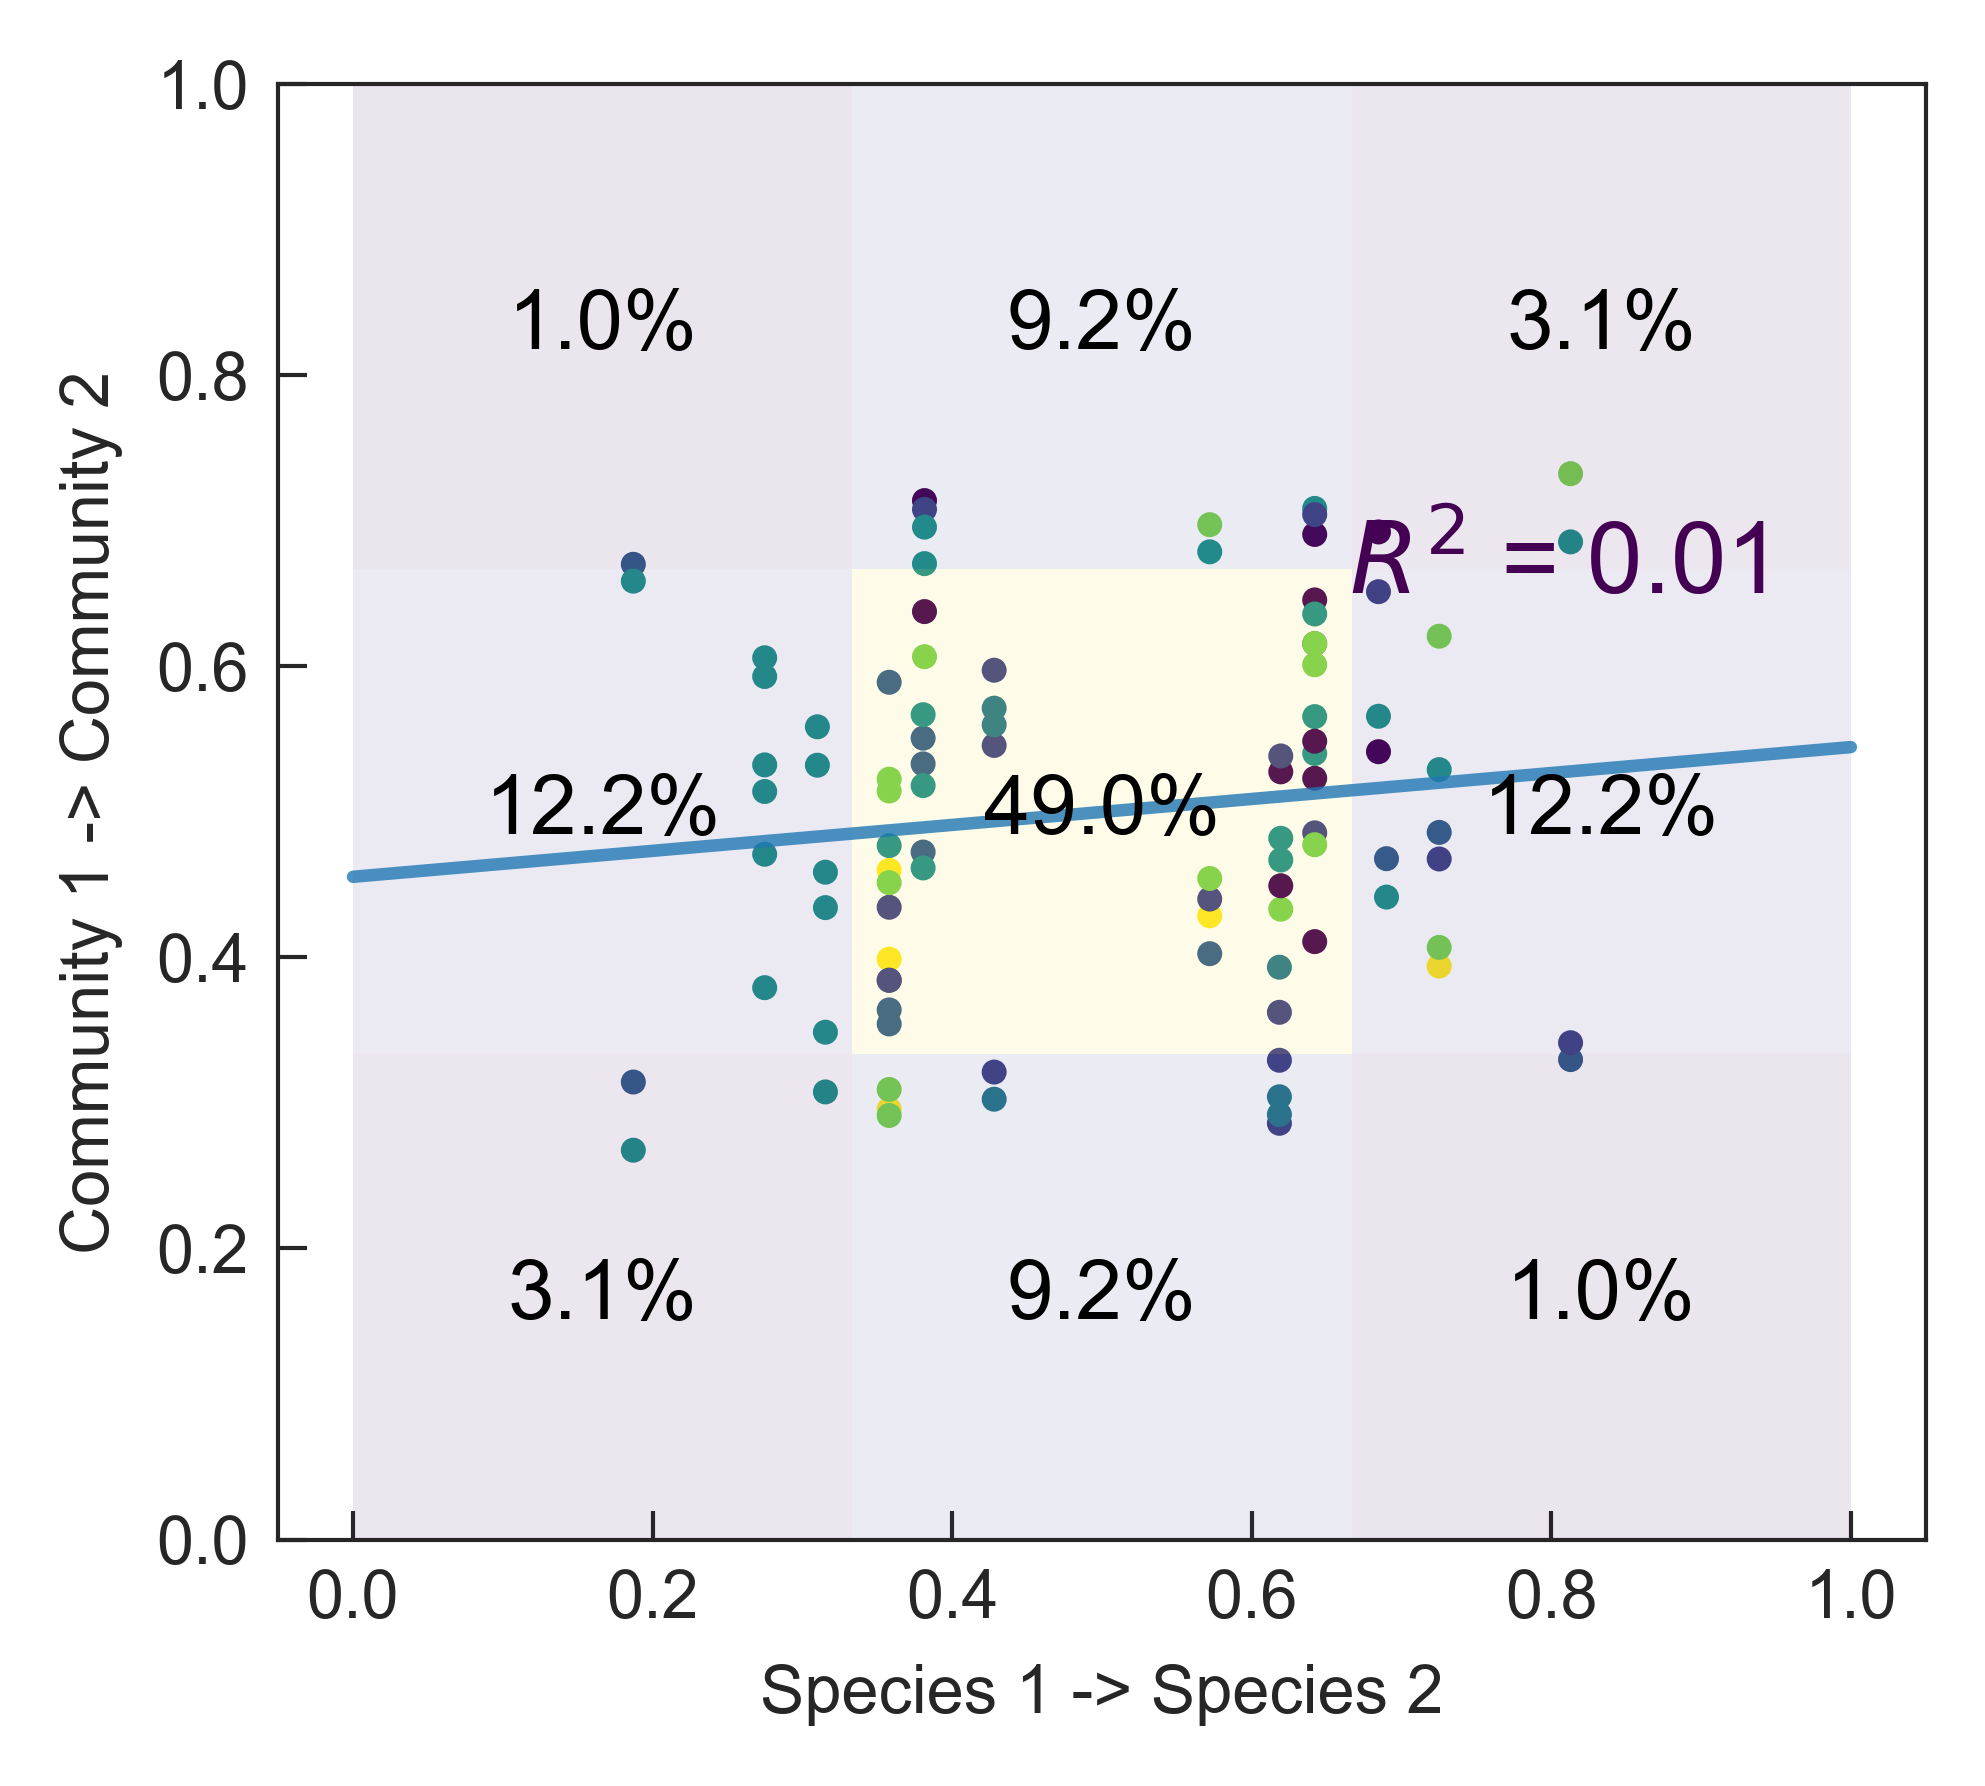

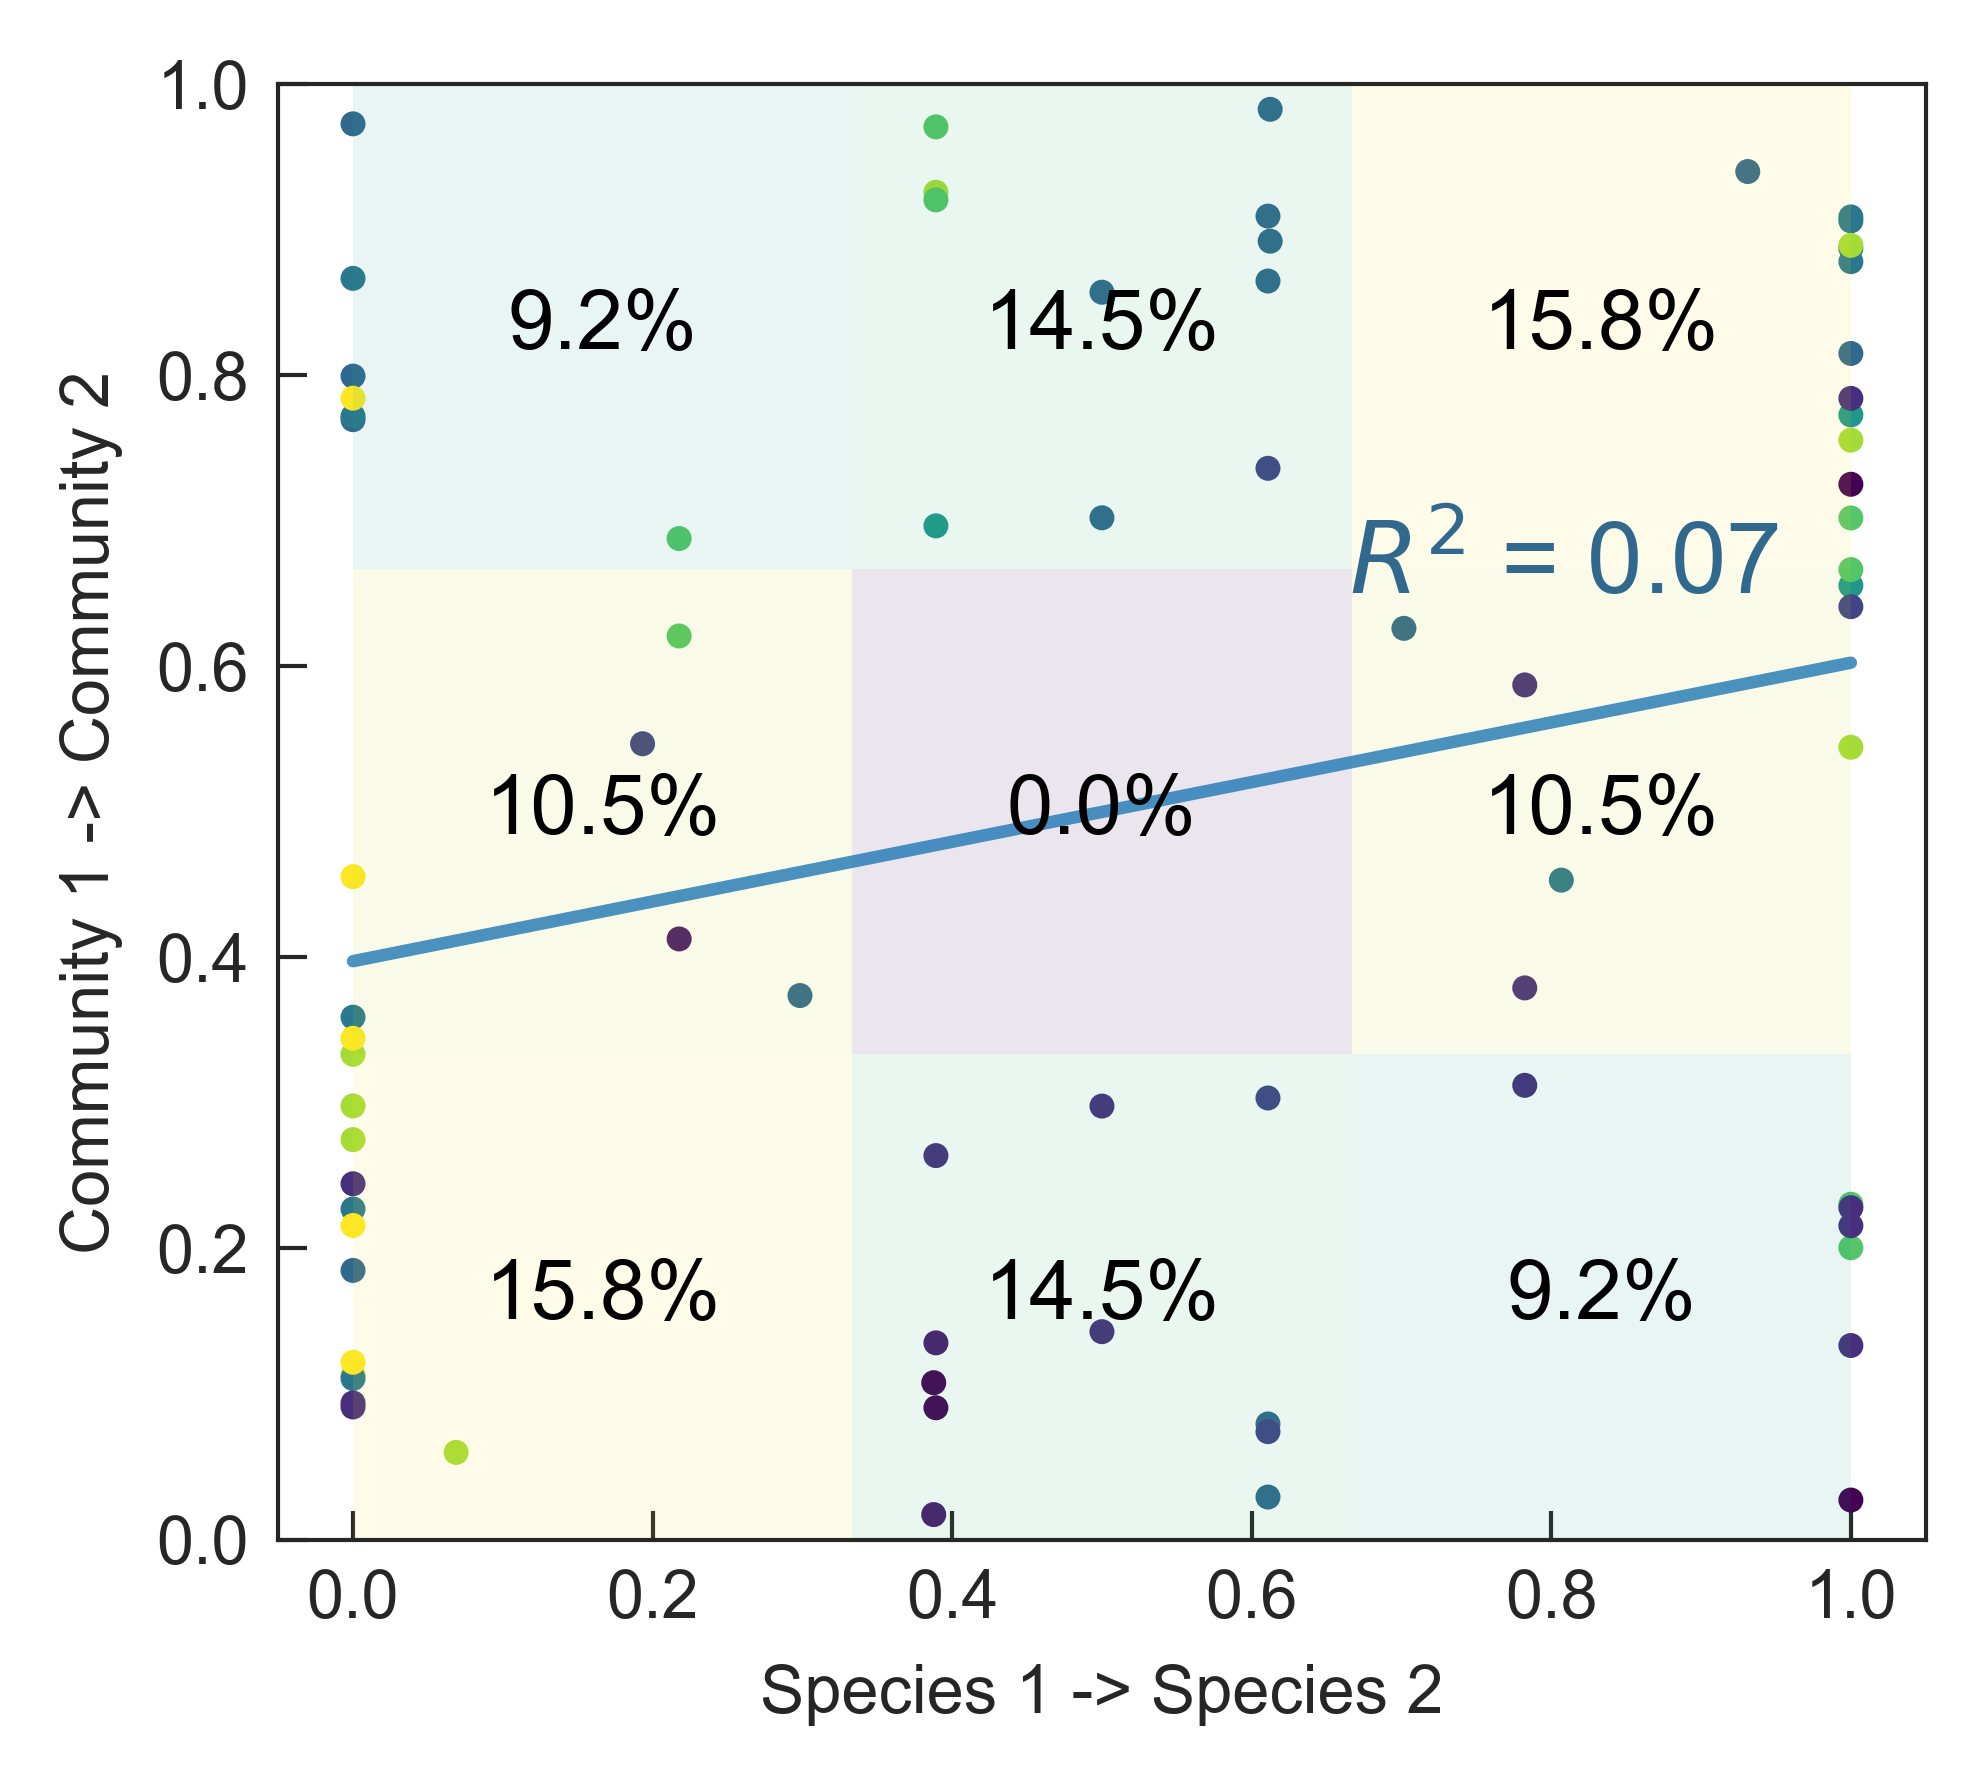

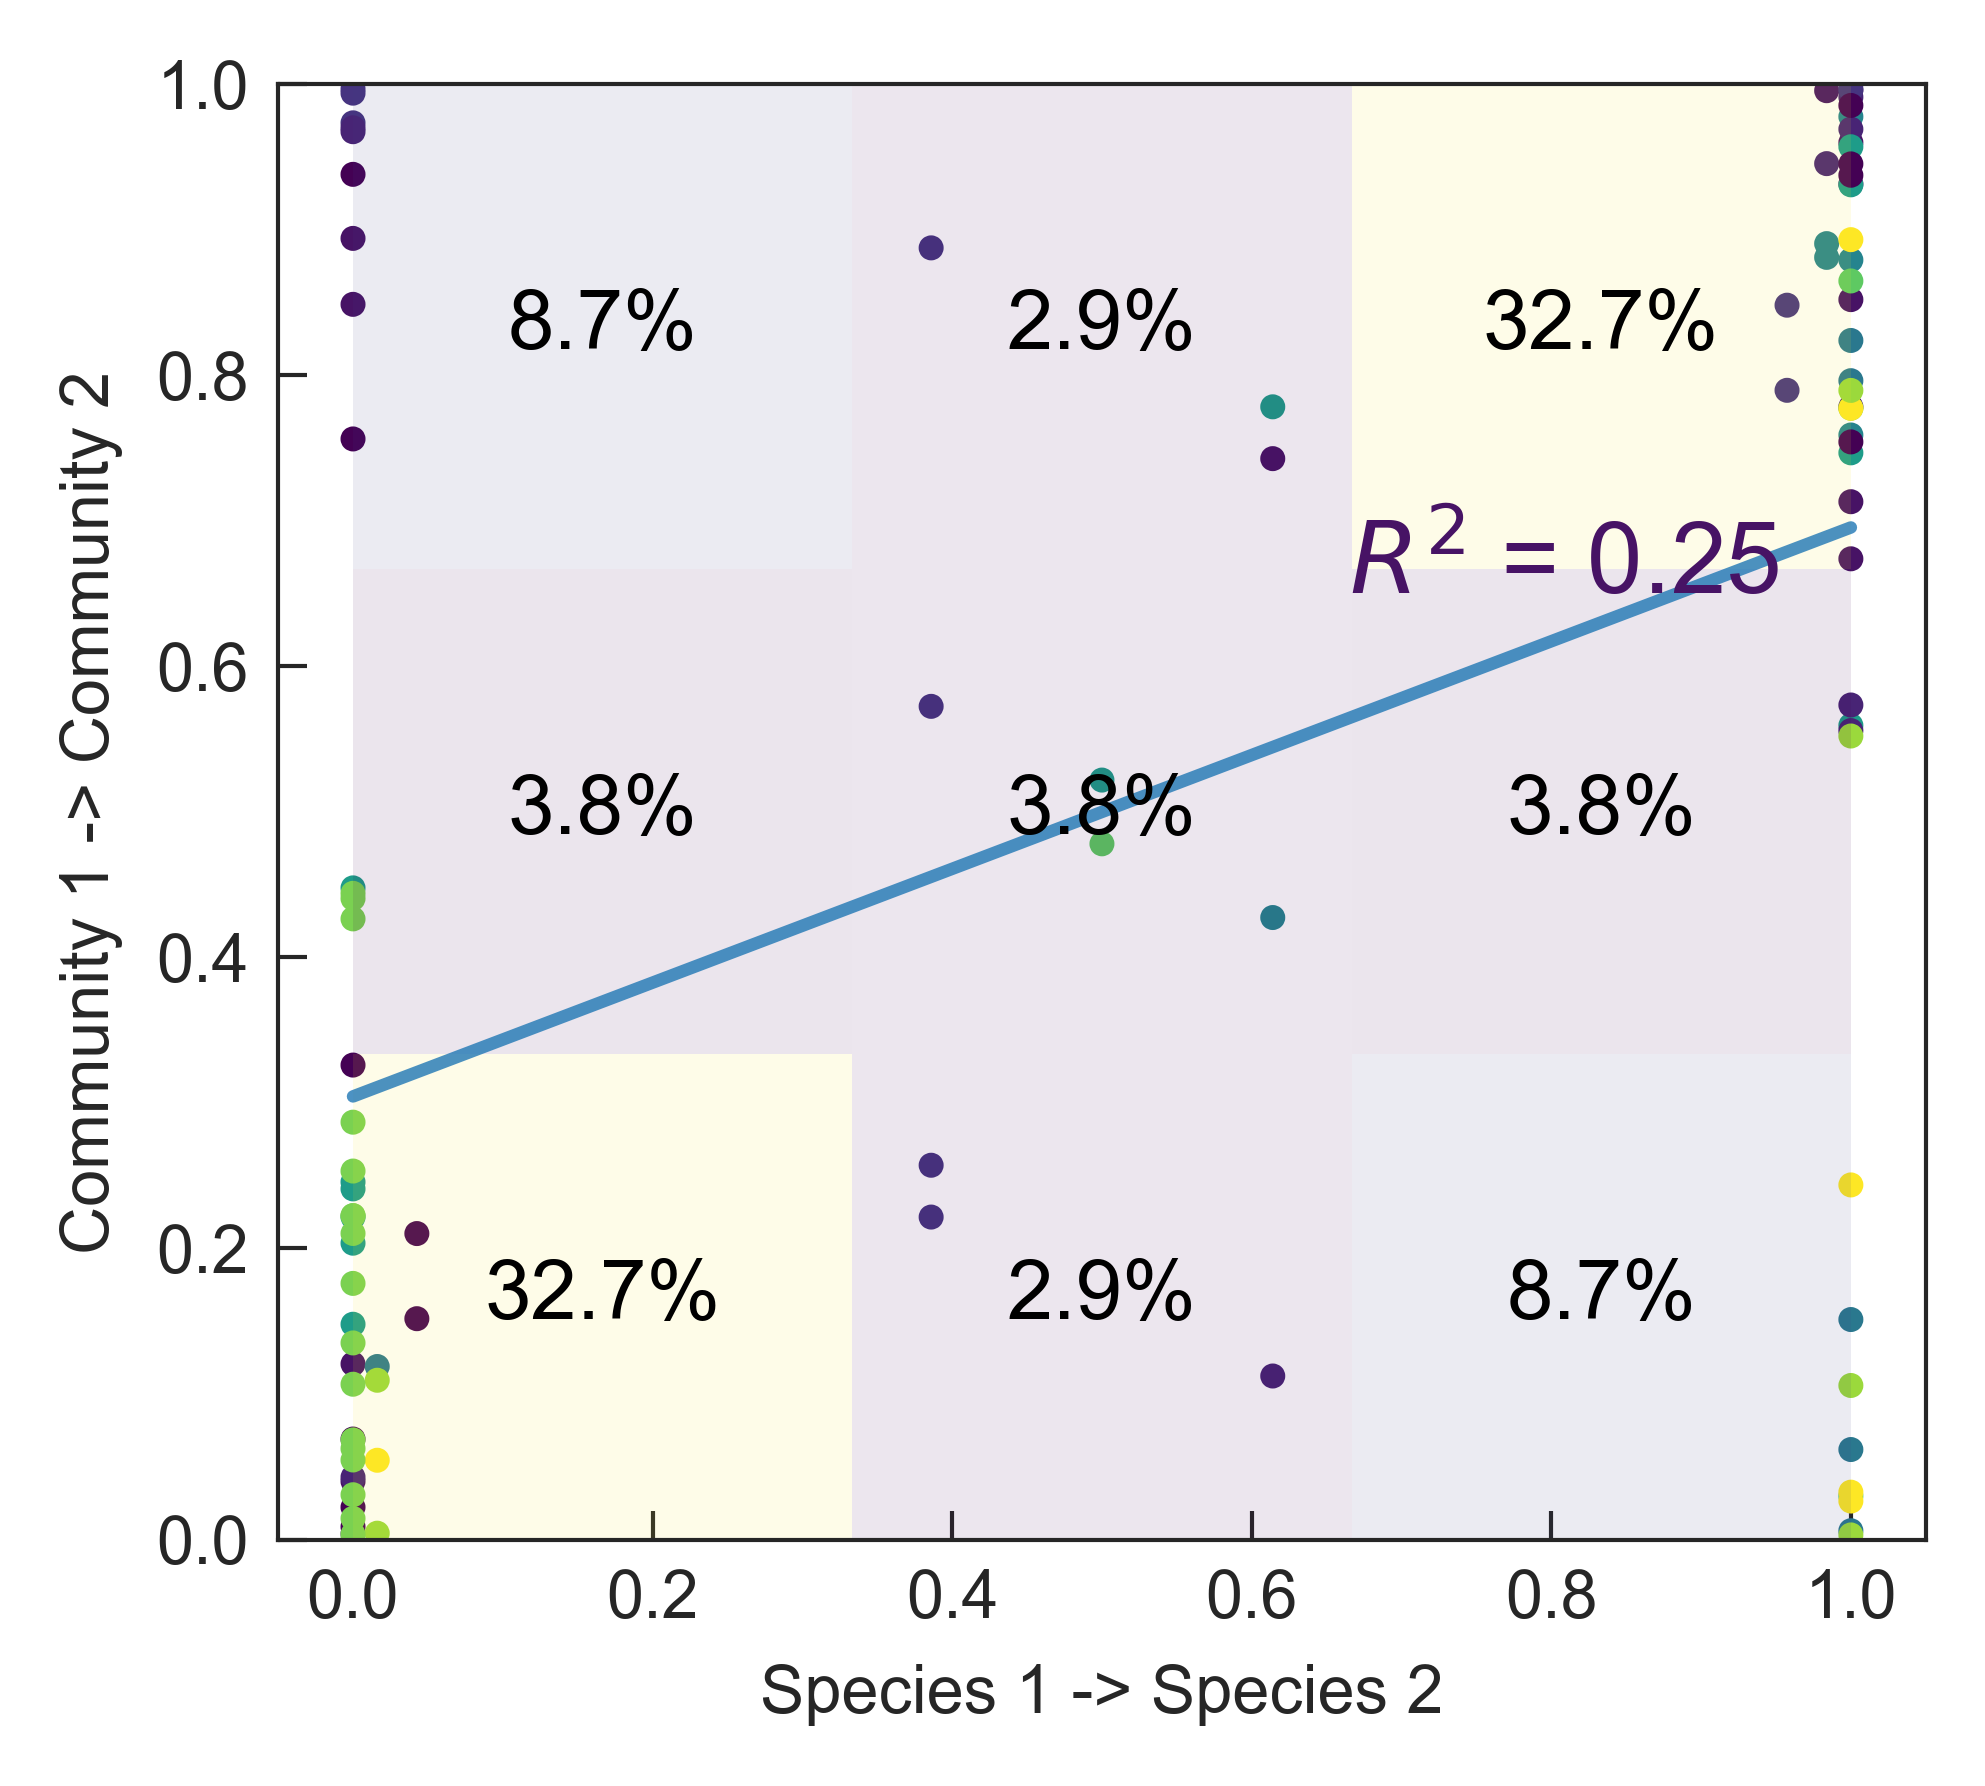

In [14]:
## Second choice : Include every species number together

# Set community Variable
Variable2plot='SimilarityTo1_BC_5'
medium="H"
species_num=12
com_type="S"
rep=-1


for c_i, medium in enumerate(['L', 'M', 'H']):
    data_p_1,data_p_2,data_flag,data_p_ratio=getProcessedPairwiseCountData(Mono_Count_data, Pairwise_Count_data, medium+'N')

    # Set Hyper parameter Variable
    alphas=np.logspace(-5, -1, num=2)
    betas=np.logspace(-2, 2, num=10)
    order=1
    preprocess='Tan' ##'Basic', 'Normalize', 'ArcTanh'

    IDX_list=np.array([])
    x=np.array([[]])
    y=np.array([])
    threshold=1e-3

    plt.subplots(1,1, figsize=(90*mm,80*mm))


    for species_num in [12]:

        Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
        Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

        matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
        df = pd.DataFrame(matrix)
        df_sorted=df.sort_index(axis=1)
        df_sorted=df_sorted.sort_index(axis=0)
        competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

        # Sort rows and columns by competitive score
        sorted_idx = np.argsort(competitive_scores)[::-1]
        df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
        competitive_scores_sorted = [np.mean(df_sorted.loc[row_col,:]) for row_col in df_sorted.index]
        x_list= getAbundance_fromList(Processed_sequences_synthetic,df_sorted.keys())

        x=[]
        y=[]
        div=[]
        mostAb=[]
        count_noncase=0
        count_total=0
        for i in range(len(df_sorted.keys())):
            for j in range(len(df_sorted.keys())):
                Coal_val=df_sorted.values[i,j]

                if ~isnan(Coal_val) and Coal_val!=0.5:
                    C1=x_list[i,:]
                    C1=argmax(C1)
                    C2=x_list[j,:]
                    C2=argmax(C2)
                    if data_p_ratio[C1,C2]==None:
                        count_total=count_total+1
                        count_noncase=count_noncase+1
                    else:
                        count_total=count_total+1
                        y.append(Coal_val)
                        mostAb.append((C1,C2))
                        x.append(np.mean([1-data_p_ratio[C1,C2],data_p_ratio[C2,C1]]))
                        #div.append(np.sum(x_list[i,:]>threshold)*np.sum(x_list[j,:]>threshold))
                        div.append(np.sum(x_list[i,:]>threshold))
    x=np.array(x)
    y=np.array(y)
    
    # Count how many points align between species-level and community-level
    x = np.array(x)
    y = np.array(y)

    # Aligned: both above or both below 0.5
    aligned_mask = ((x > 0.5) & (y > 0.5)) | ((x < 0.5) & (y < 0.5))
    num_aligned = np.sum(aligned_mask)
    total_points = len(x)

    fraction_aligned = num_aligned / total_points

    print(f'Aligned points: {num_aligned} / {total_points} = {fraction_aligned:.3f}')


    print(count_noncase,count_total)

    colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable

    if True:
        i=1

        N_values=np.array(div)
        norm = Normalize(vmin=min(N_values), vmax=max(N_values))
        normalized_N = [norm(x) for x in N_values]

        # Choose a colormap
        colormap = plt.get_cmap('viridis')

        # Map normalized N values to colors
        colors = [colormap(x) for x in normalized_N]





        plt.scatter(x,y,s=0.5)
        slope, intercept = np.polyfit(x, y, 1)
        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
            # Create a scatter plot of the data
        plt.scatter(x, y, color=colors, s=4)
        # Add the linear regression line to the plot
        plt.plot([0,1], slope * np.array([0,1]) + intercept, alpha=0.8)
                    # Add the R-squared value to the plot
        plt.annotate('$R^2$ = {:.2f}'.format(r_squared), xy=(0.05+0.6, 0.65), xycoords='axes fraction', fontsize=12, color=colors[i])


        if True:
            # Define the section size
            section_size = 1.0/3+1e-8

            # Create a grid of sections
            sections_x = np.arange(0, 1.1, section_size)
            sections_y = np.arange(0, 1.1, section_size)
            count_matrix = np.zeros((len(sections_x) - 1, len(sections_y) - 1))

            # Count the number of points in each section
            for i in range(len(sections_x) - 1):
                for j in range(len(sections_y) - 1):
                    x_min, x_max = sections_x[i], sections_x[i + 1]
                    y_min, y_max = sections_y[j], sections_y[j + 1]
                    count_matrix[i, j] = np.sum((x >= x_min) & (x < x_max) & (y >= y_min) & (y < y_max))

            # Assign colors based on the count of points
            colors = count_matrix.flatten()
            total_points = np.sum(count_matrix)

            # Calculate the percentage of points in each section
            percentage_matrix = (count_matrix / total_points) * 100

            # Create a colored heat map using Matplotlib's pcolormesh
            plt.pcolormesh(sections_x, sections_y, count_matrix, cmap='viridis', alpha=0.1)
            for i in range(len(sections_x) - 1):
                for j in range(len(sections_y) - 1):
                    plt.text(sections_x[i] + section_size/2, sections_y[j] + section_size/2, f'{percentage_matrix[i, j]:.1f}%', color='black', size=10, ha='center', va='center')


        plt.xlabel('Species 1 -> Species 2')
        plt.ylabel('Community 1 -> Community 2')
        plt.xlim(-0.05,1.05)

In [ ]:
# Count how many points align between species-level and community-level
x = np.array(x)
y = np.array(y)

# Aligned: both above or both below 0.5
aligned_mask = ((x > 0.5) & (y > 0.5)) | ((x < 0.5) & (y < 0.5))
num_aligned = np.sum(aligned_mask)
total_points = len(x)

fraction_aligned = num_aligned / total_points

print(f'Aligned points: {num_aligned} / {total_points} = {fraction_aligned:.3f}')
